## Дисклеймер!!!!!

Поскольку я терпеть ненавижу отвратно структурированный код, я большую часть инжиринга признаков вынес в отдельный файл. Направление действий будет видно как и указано в задании, но сразу для всего. Я не писал всё одним батчем, тут положена куча коммитов, просто для сохранения ясности я решил не сваливать всё в одну нечитабельную кучу. 

По поводу баллов - претендую на баллы за каждый из указанныз в ДЗ пунктов кроме топ-3 (пока что)

## Грузим данные

Из основных фич которые я выделил за это время:

1) Количество добавлений в корзину/поисков/просмотров
2) "Вероятность" добавления в корзину при наличии клика по товару
3) Статистики по количествуй действий за каждую сессию (40 минут)
4) Последние 3/2/1 действия(е)
5) TFIDF + SVD по тексту поиска
6) Флаги на запросы по самым популярным продуктам питания
7) Количество уникальных запросов
8) Статистики по длине запроса в словах/символях (медианная, максимальная, средняя)
9) Последний запрос, его длина в символах и словах
10) Средняя/максимальная/минимальная цена просмотренного товара
11) Доля товаров купленных по скидке
12) Среднее значение скидки
13) Доля наиболее частой категории товаров

+ все признаки которые были в преложенном решении

Скор - 0.81949

### UPD
Добавил в `embedding_features` колонку-список эмбеддингов поиска TFIDF+SVD, результат только ухудшился (примерно на 0.002)

### UPD 2
Добавил ещё кучу признаков:

14)  Динамика активности
- Количество действий за последние 7/30 дней и за предыдущие периоды (предыдущие 7 и 30 дней)
- Отдельно считаются: клики, добавления в корзину, заказы, поиски, уникальные товары
- Разности между окнами (например: actions_last_7d - actions_prev_7d)
- Отношения между окнами (например: (actions_last_7d + 1) / (actions_prev_7d + 1))
- Аналогичные признаки для кликов, корзины, заказов и поисков

15)  Конверсия поиска в действия
- Количество переходов:
  - search → click в течение 5 / 30 / 60 минут
  - search → to_cart в течение 5 / 30 / 60 минут
- Среднее время от поиска до клика
- Среднее время от поиска до добавления в корзину
- Нормированные коэффициенты:
  - search_to_click_rate
  - search_to_cart_rate

16)  Признаки по виджетам
- Общее количество действий через виджеты
- Количество уникальных виджетов
- Самый частый виджет (favorite_widget)
- Последний использованный виджет
- Доля действий из самого частого виджета (favorite_widget_share)
- Энтропия распределения по виджетам
- Доли действий в топ-K наиболее популярных виджетах

17)  Повторяемость и лояльность
- Количество уникальных товаров, категорий, брендов
- Количество повторных взаимодействий (один и тот же объект более одного раза)
- Доля повторных товаров 
- Доля повторных категорий
- Доля повторных брендов
- Доля наиболее популярного товара/категории/бренда
- Повторяемость отдельно для действий:
  - click
  - to_cart
  - order

Скор - 0.81987

In [1]:
from data_preparation import OzonDataFormer
from datetime import date
import pandas as pd

In [2]:
data_params = {
    'include_actions': True,
    'include_search': True,
    'include_price': True,
    # UPD
    'group_embedding': False,
    # UPD 2
    'include_trend': True,
    'include_action_conversion': True,
    'include_repeat_loyalty': True,
    'include_widget': False,
}

In [3]:
do_construct = False

In [4]:
if do_construct:
    former = OzonDataFormer()
    former.fit_text_vectorizer(feature_end_date=date(2024, 5, 31))
    train_df = former.construct_dataset(
        feature_end_date=date(2024, 5, 31),
        target_start_date=date(2024, 6, 1),
        target_end_date=date(2024, 6, 30),
        **data_params
    )
    val_df = former.construct_dataset(
        feature_end_date=date(2024, 6, 30),
        target_start_date=date(2024, 7, 1),
        target_end_date=date(2024, 7, 31),
        **data_params
    )
    train_df.to_parquet('data/train.parquet',
                        index=False, engine='fastparquet')
    val_df.to_parquet('data/val.parquet',
                      index=False, engine='fastparquet')
else:
    train_df = pd.read_parquet('data/train.parquet', engine='fastparquet')
    val_df = pd.read_parquet('data/val.parquet', engine='fastparquet')

In [5]:
X_train = train_df.drop(columns=['user_id', 'target'])
y_train = train_df['target']

In [6]:
X_val = val_df.drop(columns=['user_id', 'target'])
y_val = val_df['target']

In [7]:
from utils2 import AutoFeatureStandardizer

In [8]:
standardizer = AutoFeatureStandardizer()

In [9]:
X_train = standardizer.fit_transform(X_train)

/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:2039: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_out[f"{col}_is_nan"] = np.isnan(x).astype(float)
/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:2039: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_out[f"{col}_is_nan"] = np.isnan(x).astype(float)
/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:2039: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at on

In [10]:
X_val = standardizer.transform(X_val)

/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:2039: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_out[f"{col}_is_nan"] = np.isnan(x).astype(float)
/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:2039: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_out[f"{col}_is_nan"] = np.isnan(x).astype(float)
/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:2039: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at on

In [11]:

import gc

gc.collect()
del train_df
del val_df

## Проверка адекватности разделения на тренировку и валидацию

In [12]:
import numpy as np

In [13]:
cat_features = list(X_train.select_dtypes('category').columns)

In [14]:
embedding_features = ['search_emb'] if 'search_emb' in X_train.columns else None

In [15]:
from catboost.utils import get_gpu_device_count

if get_gpu_device_count() > 0:
    task_type = 'GPU'
else:
    task_type = 'CPU'

params = {
    'iterations': 100,
    'depth': 7,
    'random_state': 1,
    'eval_metric': 'AUC',
    'loss_function': 'Logloss',
    'auto_class_weights': 'Balanced',
    'task_type': task_type,
    'cat_features': cat_features,
    'embedding_features': embedding_features
}

# search_tfidfsvd

In [16]:
from validation_check import get_train_val_difference

# diff_score, _, _ = get_train_val_difference(X_train, y_train, X_val, y_val, params)

In [17]:
# diff_score

Скор получился примерно 0.78. Ну выглядит вроде адекватно учитывая что в данных очевидно есть временная зависимость

### UPD
Периодически при добавлении новых признаков скор менялся от 0.7 до 0.85. Всё ещё норм, опять же дрифт временных данных тут играет свою роль.

## Обучение модели

In [18]:
from catboost import CatBoostClassifier, Pool

In [19]:
cat_features

['last_2_action', 'last_3_action', 'last_3_actions_str', 'last_action']

In [20]:
train_pool = Pool(
    X_train,
    label=y_train,
    cat_features=params.get('cat_features'),
    embedding_features=params.get('embedding_features')
)

val_pool = Pool(
    X_val,
    label=y_val,
    cat_features=params.get('cat_features'),
    embedding_features=params.get('embedding_features')
)

In [21]:
params['iterations'] = 5000

model = CatBoostClassifier(**params)

In [22]:
model_name = "models/combined.bin"

try:
    model.load_model(model_name)
except Exception:
    model.fit(
        train_pool,
        eval_set=val_pool,
        use_best_model=True,
        verbose=10,
        early_stopping_rounds=50,
    )
    model.save_model(model_name)

In [23]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

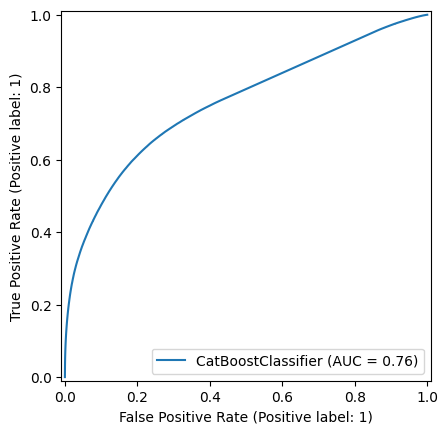

In [24]:
RocCurveDisplay.from_estimator(model, X_val, y_val)

## Интерпретация модели

In [25]:
from utils2 import AutoFeatureStandardizer, BinaryClassifierInterpreter
from cluster_compare import NotebookBinaryClusterInterpreter
from bokeh.io import output_notebook

In [26]:
import panel as pn
pn.extension()

In [27]:
output_notebook()

tool = NotebookBinaryClusterInterpreter(
    X=X_train.loc[::30],
    y=y_train.loc[::30],
)
tool.show()

Loading BokehJS ...

/home/i3alumba/Projects/AI/aim_ml/.venv/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


BokehModel(combine_events=True, render_bundle={'docs_json': {'dbf82475-20c1-4d0e-b192-d72ad903c7d5': {'version…

А выглядит интересно, чётко видны 2 кластера, надо посмотреть чё там такое.

### UPD
Я добавил соотношение меток классов к кластерам, получается интересная картина. В левом кластере оба класса представлены $\pm$ одинаково, а во втором соотношение примерно 50/50. Мб имеет смысл использовать результаты кластеризации как признаки для модели, но надо хорошо подумать над алгоритмом кластеризации

### UPD 2
Я добавил SHAP, к сожалению никаких особых откровений. По большому счёту - разделение пользователей по активности.

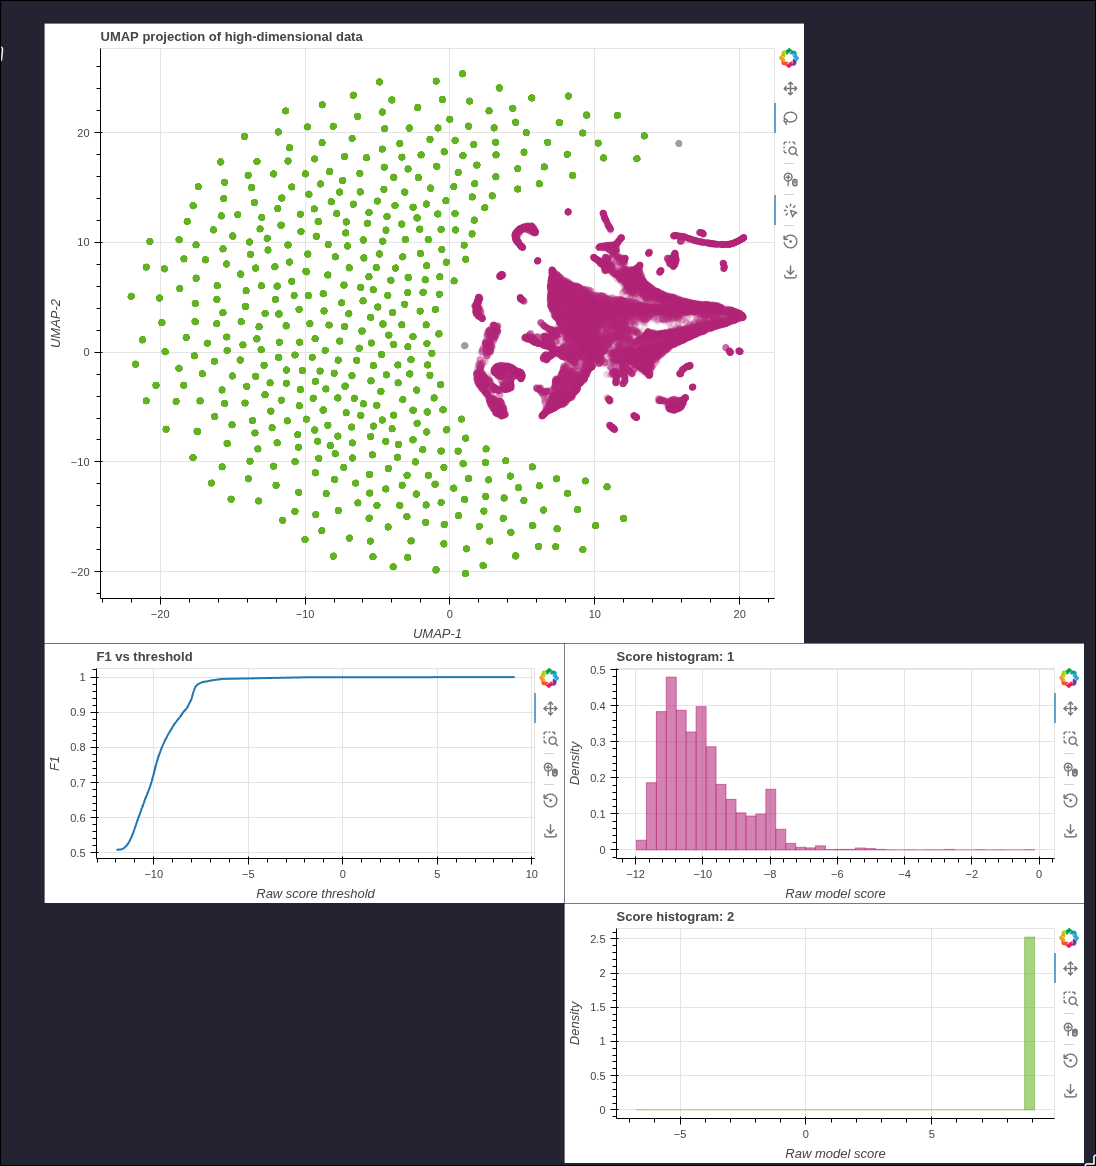

In [28]:
interpreter = BinaryClassifierInterpreter(
    train=(X_train[::30], y_train[::30]),
    val=(X_val[::10], y_val[::10]),
    model=model
)

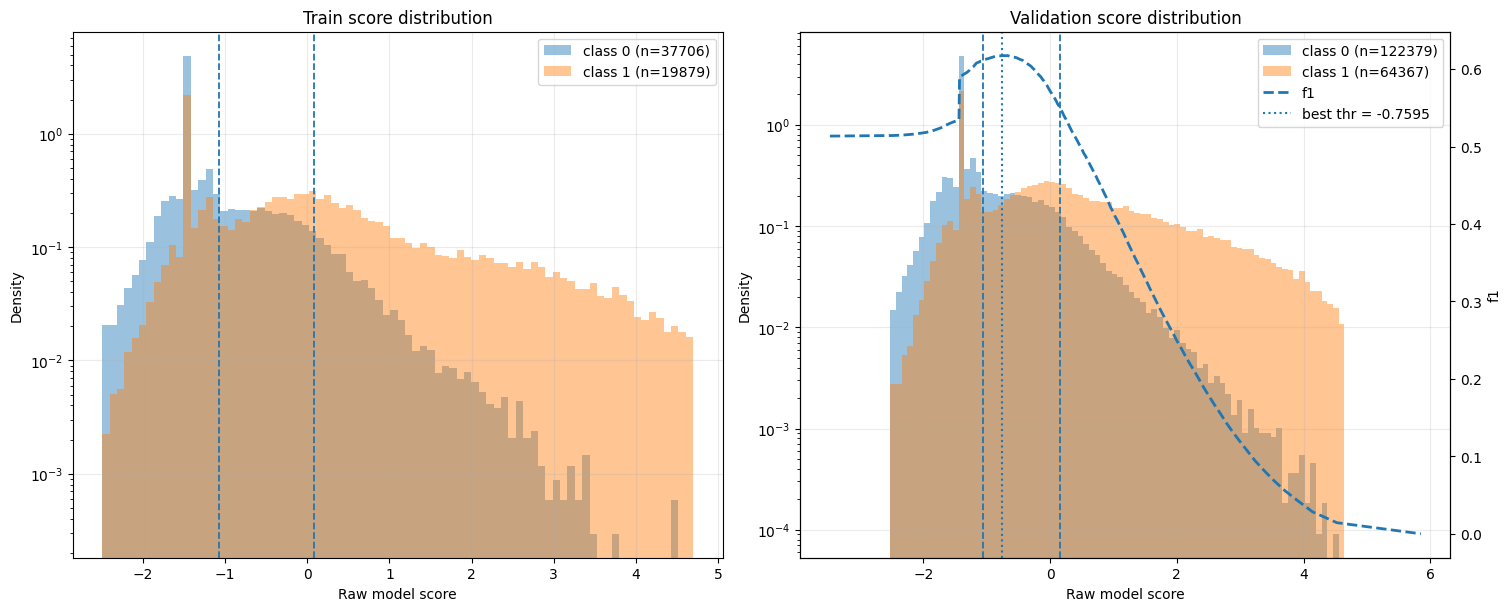

In [29]:
interpreter.plot_score_histograms_with_val_metric(val_metric_name="f1", use_log_density_y=True);

In [30]:
interpreter.plot_float_feature_histograms()

In [31]:
interpreter.plot_score_feature_contours()

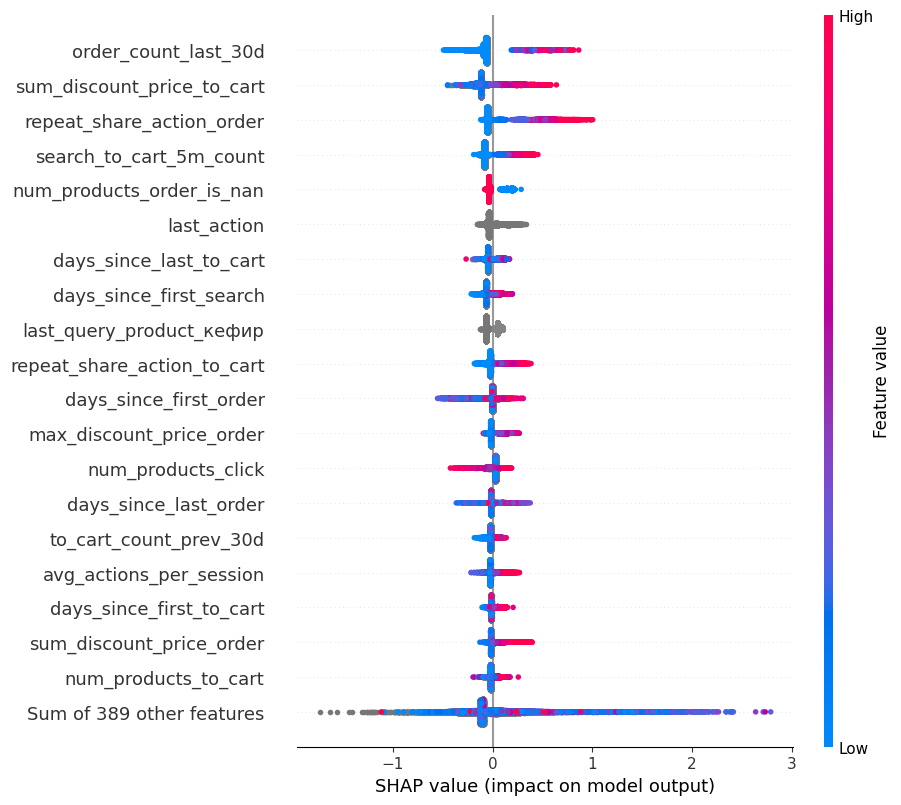

In [32]:
interpreter.plot_shap_beeswarm(sample_frac=0.1);

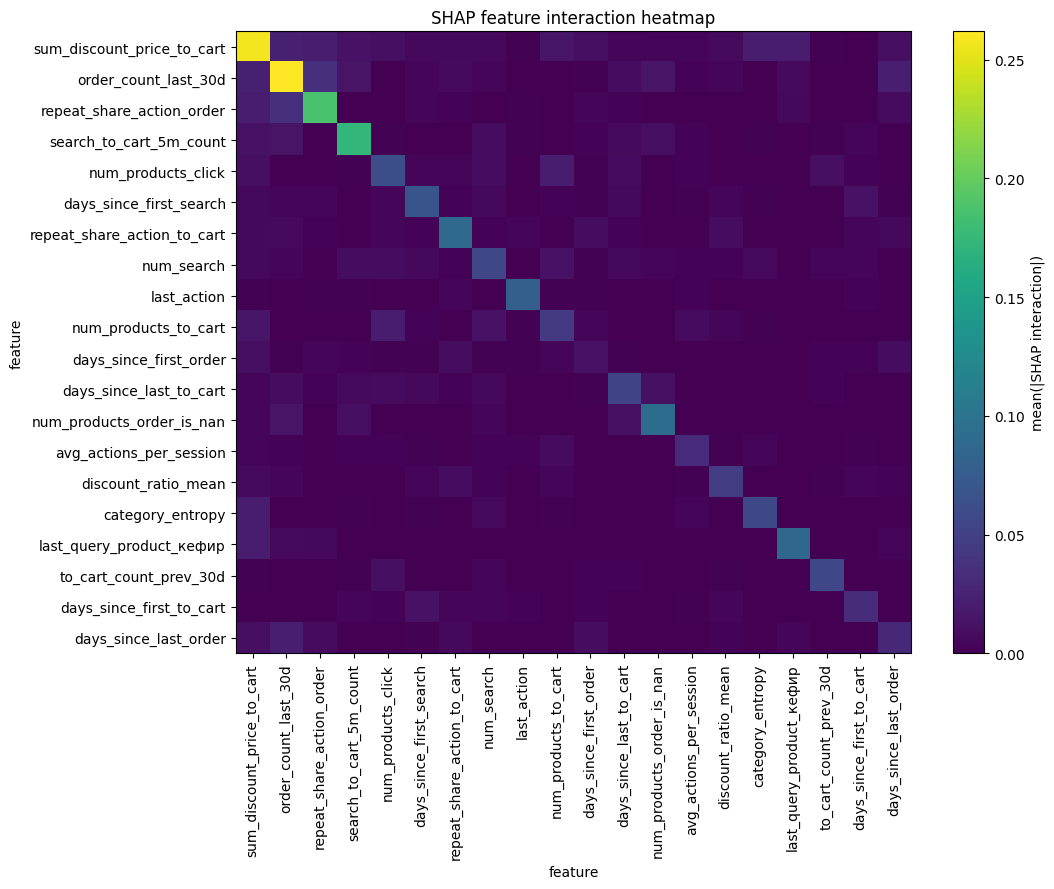

In [33]:
interpreter.plot_shap_interaction_heatmap();

Пока не видно признаков с сильным взаимодействием, посмотрим когда появятся новые

### UPD Добавил новые фишки к интерпретатору
Добавление новых признаков ухудшило результат, будем резать. Чтобы резать нужно определиться с ненужными фичами - константы, дубликаты, линейно зависимые и плохо влияющие на скор

In [34]:
constant_features = interpreter.find_constant_features()
duplicate_features = interpreter.find_duplicate_features()
high_corr = interpreter.find_high_corr_features(threshold=0.9)

print("constant:", len(constant_features))
print("duplicate pairs:", len(duplicate_features))
print("high corr drop candidates:", len(high_corr))

constant: 0
duplicate pairs: 163
high corr drop candidates: 235


,feature,perm_importance_mean,perm_importance_std
0,order_count_last_30d,0.019728,0.000437
1,sum_discount_price_to_cart,0.007065,0.000418
2,num_products_click,0.004983,0.000586
3,num_search,0.003803,0.000393
4,num_products_to_cart,0.002749,0.000352
5,repeat_share_action_order,0.002669,0.000126
6,category_entropy,0.002620,0.000269
7,days_since_first_search,0.002607,0.000274
8,num_products_order_is_nan,0.002197,0.000186
9,days_since_last_search_right,0.001987,0.000320


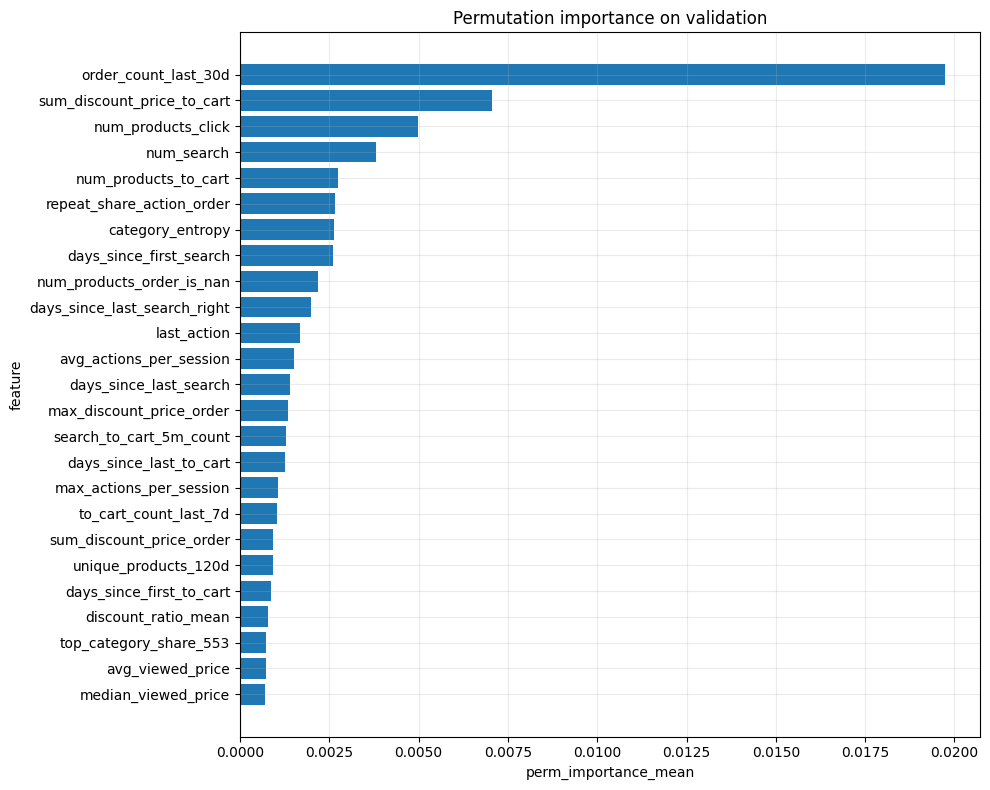

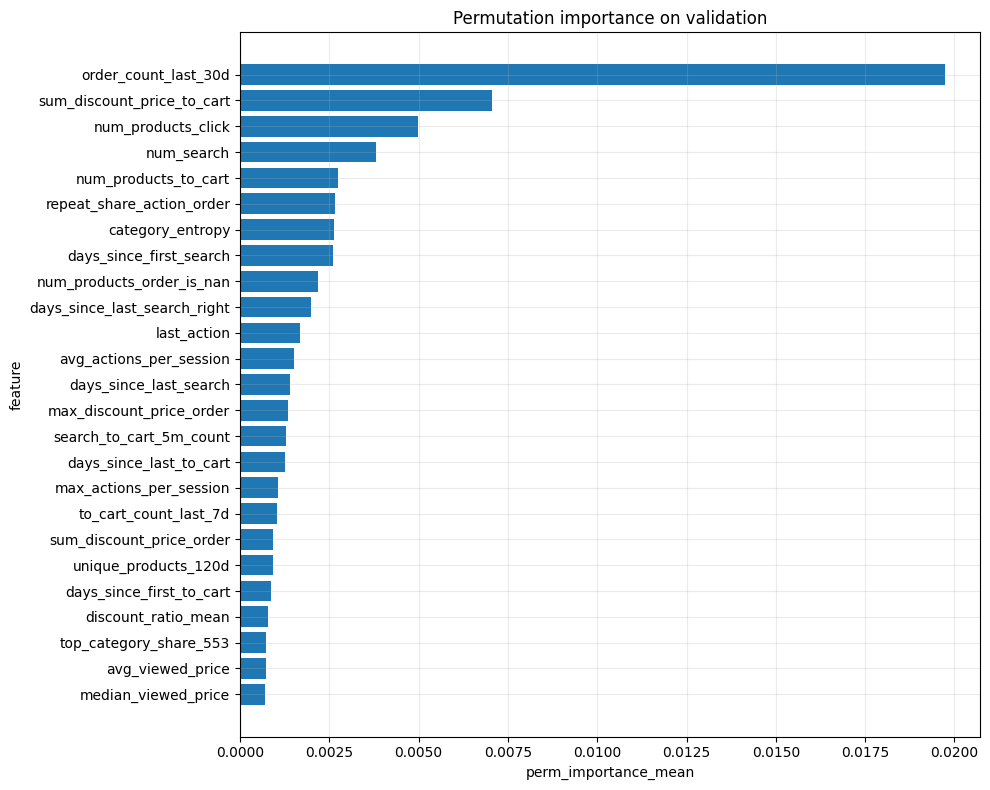

In [35]:
perm_df = interpreter.get_permutation_importance(
    n_repeats=5,
    scoring="roc_auc",
    refit=False
)
display(perm_df.head(30))

interpreter.plot_feature_importance_table(
    perm_df,
    value_col="perm_importance_mean",
    title="Permutation importance on validation",
)

In [36]:
gc.collect()

811

In [37]:
ablation_res = interpreter.analyze_feature_ablation(
    features=perm_df["feature"].head(80).tolist()
)
display(ablation_res.table.head(30))

100%|██████████| 80/80 [20:18<00:00, 15.23s/it]


,feature,roc_auc,pr_auc,logloss,delta_roc_auc,delta_pr_auc,delta_logloss
0,days_since_first_to_cart,0.747838,0.667489,0.536157,0.001729,0.000784,0.001582
1,days_since_last_click,0.747787,0.669000,0.532936,0.001679,0.002296,-0.001639
2,avg_query_len_words_30d,0.747348,0.668026,0.534116,0.001239,0.001322,-0.000459
3,median_viewed_price,0.747329,0.668571,0.534074,0.001220,0.001867,-0.000501
4,num_products_favorite,0.747209,0.667171,0.534426,0.001100,0.000467,-0.000149
5,search_events_30d,0.747073,0.668212,0.534252,0.000964,0.001508,-0.000323
6,avg_viewed_price,0.746890,0.668274,0.534314,0.000782,0.001570,-0.000261
7,repeat_category_rate,0.746818,0.667160,0.534920,0.000710,0.000456,0.000345
8,days_since_last_favorite,0.746780,0.667375,0.534179,0.000671,0.000671,-0.000395
9,max_discount_price_to_cart,0.746749,0.667646,0.534326,0.000640,0.000942,-0.000249


In [38]:
ablation_res.table.to_csv('feature_importance.csv')

In [39]:
suggestion = interpreter.suggest_features_to_drop(
    corr_threshold=0.995,
    perm_threshold=0.0,
    ablation_min_delta=0.0,
    n_perm_repeats=5,
    max_ablation_features=100,
)

print("constant:", suggestion.constant_features)
print("duplicate:", suggestion.duplicate_features[:10])
print("high corr:", suggestion.high_corr_drop_candidates[:20])
print("low importance:", suggestion.low_importance_features[:20])
print("harmful by ablation:", suggestion.harmful_features_by_ablation[:20])

100%|██████████| 100/100 [26:24<00:00, 15.85s/it]

constant: []
duplicate: [('days_since_last_search', 'days_since_last_search_right'), ('favorite_category_cnt_120d', 'favorite_category_count'), ('favorite_category_share', 'favorite_category_share_120d'), ('search_count_30d_right', 'search_events_30d'), ('total_category_events', 'total_category_events_120d'), ('unique_categories', 'unique_categories_120d'), ('search_count_30d', 'view_count_30d'), ('actions_trend_delta_7d_is_nan', 'actions_trend_ratio_7d_is_nan'), ('avg_query_len_chars_30d_is_nan', 'avg_query_len_words_30d_is_nan'), ('add_to_cart_count_30d_is_nan', 'cart_to_click_ratio_is_nan')]
high corr: ['days_since_last_search_right', 'favorite_category_count', 'product_банан_flag_rate_30d', 'product_батон_flag_rate_30d', 'product_йогурт_flag_rate_30d', 'product_кефир_flag_rate_30d', 'product_колбас_flag_rate_30d', 'product_кофе_flag_rate_30d', 'product_курица_flag_rate_30d', 'product_творог_flag_rate_30d', 'product_чай_flag_rate_30d', 'product_шоколад_flag_rate_30d', 'product_яблок

Проверка 1

constant: []

duplicate: [('days_since_last_search', 'days_since_last_search_right'), ('favorite_category_cnt_120d', 'favorite_category_count'), ('favorite_category_share', 'favorite_category_share_120d'), ('search_count_30d_right', 'search_events_30d'), ('total_category_events', 'total_category_events_120d'), ('unique_categories', 'unique_categories_120d'), ('search_count_30d', 'view_count_30d'), ('actions_trend_delta_7d_is_nan', 'actions_trend_ratio_7d_is_nan'), ('avg_query_len_chars_30d_is_nan', 'avg_query_len_words_30d_is_nan'), ('add_to_cart_count_30d_is_nan', 'cart_to_click_ratio_is_nan')]

high corr: ['days_since_last_search_right', 'favorite_category_count', 'product_банан_flag_rate_30d', 'product_батон_flag_rate_30d', 'product_йогурт_flag_rate_30d', 'product_кефир_flag_rate_30d', 'product_колбас_flag_rate_30d', 'product_кофе_flag_rate_30d', 'product_курица_flag_rate_30d', 'product_творог_flag_rate_30d', 'product_чай_flag_rate_30d', 'product_шоколад_flag_rate_30d', 'product_яблок_flag_rate_30d', 'product_яйца_flag_rate_30d', 'queries_with_product_keywords_30d', 'search_events_30d', 'search_to_cart_60m_count', 'search_to_click_60m_count', 'total_category_events', 'total_category_events_120d']

low importance: ['repeat_category_rate_is_nan', 'repeat_categories_120d_is_nan', 'repeat_share_action_click_is_nan', 'product_яблок_flag_rate_30d_is_nan', 'last_query_product_батон', 'fraction_discounted_products', 'product_хлеб_flag_rate_30d_is_nan', 'last_query_product_хлеб', 'product_яйца_flag_rate_30d_is_nan', 'favorite_product_share', 'last_query_product_яблок', 'unique_searches_trend_delta_7d_is_nan', 'favorite_category_share', 'product_шоколад_flag_rate_30d_is_nan', 'product_шоколад_flag_count_30d_is_nan', 'product_чай_flag_rate_30d_is_nan', 'product_чай_flag_count_30d_is_nan', 'top_category_share_829_is_nan', 'total_brand_events_120d_is_nan', 'total_category_events_is_nan']

harmful by ablation: ['total_brand_events_120d_is_nan', 'repeat_brands_120d_is_nan', 'repeat_brand_rate_is_nan', 'view_count_30d_is_capped', 'unique_searches_trend_delta_7d_is_nan', 'product_колбас_flag_rate_30d_is_nan', 'product_кефир_flag_rate_30d_is_nan', 'product_хлеб_flag_rate_30d_is_nan', 'product_шоколад_flag_count_30d_is_nan', 'product_йогурт_flag_rate_30d_is_nan', 'product_шоколад_flag_rate_30d_is_nan', 'product_чай_flag_count_30d_is_nan', 'product_хлеб_flag_count_30d_is_nan', 'product_творог_flag_rate_30d_is_nan', 'product_сыр_flag_rate_30d_is_nan', 'product_творог_flag_count_30d_is_nan', 'product_сыр_flag_count_30d_is_nan', 'product_чай_flag_rate_30d_is_nan', 'product_молоко_flag_count_30d_is_nan', 'product_курица_flag_rate_30d_is_nan']

In [48]:
import json

with open('drop.json', 'wt', encoding='utf-8-sig') as f:
    json.dump(suggestion.__dict__, f) 

## Тюнинг параметров


Скор - 0.82092

In [ ]:
do_tune = False

In [ ]:
import optuna
from sklearn.metrics import roc_auc_score

In [ ]:
def objective(trial: optuna.Trial):
    eta = trial.suggest_float("eta", 1e-3, 1.0, log=True)
    depth = trial.suggest_int("depth", 5, 10)
    
    params['eta'] = eta
    params['depth'] = depth
        
    model = CatBoostClassifier(**params)

    model.fit(
        train_pool,
        eval_set=val_pool,
        use_best_model=True,
        verbose=False,
        early_stopping_rounds=50,
    )

    preds = model.predict_proba(X_val)[:, 1]
    
    score = roc_auc_score(y_val, preds)
    return score

In [ ]:
if do_tune:
    study = optuna.create_study(direction='maximize')
    params['iterations'] = 500
    study.optimize(objective, n_trials=100)
    
    from optuna.visualization import plot_contour
    from plotly.io import show
    
    fig = plot_contour(study)

    show(fig)
    
    best_params = study.best_params
else:
    best_params = {'eta': 0.055848570897405615, 'depth': 8}

[I 2026-04-15 23:41:28,017] A new study created in memory with name: no-name-958e75e6-e1db-445e-b66f-4b1b0ce3f914
Default metric period is 5 because AUC is/are not implemented for GPU
[I 2026-04-15 23:42:29,987] Trial 0 finished with value: 0.7551789549495345 and parameters: {'eta': 0.006467418287896839, 'depth': 10}. Best is trial 0 with value: 0.7551789549495345.
Default metric period is 5 because AUC is/are not implemented for GPU
[I 2026-04-15 23:42:38,841] Trial 1 finished with value: 0.756233858992885 and parameters: {'eta': 0.4023576676402016, 'depth': 8}. Best is trial 1 with value: 0.756233858992885.
Default metric period is 5 because AUC is/are not implemented for GPU
[I 2026-04-15 23:43:06,126] Trial 2 finished with value: 0.7537470187123482 and parameters: {'eta': 0.005300854803994221, 'depth': 6}. Best is trial 1 with value: 0.756233858992885.
Default metric period is 5 because AUC is/are not implemented for GPU
[I 2026-04-15 23:43:27,490] Trial 3 finished with value: 0.75

In [ ]:
best_params

{'eta': 0.13349576109695457, 'depth': 5}

Лучшие параметры - {'eta': 0.09094570381895212, 'depth': 7}

In [ ]:
params.update(best_params)
params['iterations'] = 5000

## Финальное предсказание

In [ ]:
model = CatBoostClassifier(**params)

model.fit(
        train_pool,
        eval_set=val_pool,
        use_best_model=True,
        verbose=10,
        early_stopping_rounds=50,
    )
model.save_model(model_name)

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.7384985	best: 0.7384985 (0)	total: 42.3ms	remaining: 3m 31s
10:	test: 0.7518345	best: 0.7518345 (10)	total: 474ms	remaining: 3m 35s
20:	test: 0.7532445	best: 0.7532445 (20)	total: 915ms	remaining: 3m 36s
30:	test: 0.7538946	best: 0.7538946 (30)	total: 1.33s	remaining: 3m 34s
40:	test: 0.7544479	best: 0.7544479 (40)	total: 1.76s	remaining: 3m 32s
50:	test: 0.7548701	best: 0.7548701 (50)	total: 2.19s	remaining: 3m 32s
60:	test: 0.7552264	best: 0.7552305 (59)	total: 2.6s	remaining: 3m 30s
70:	test: 0.7554168	best: 0.7554168 (70)	total: 3.02s	remaining: 3m 29s
80:	test: 0.7557158	best: 0.7557158 (80)	total: 3.44s	remaining: 3m 29s
90:	test: 0.7558843	best: 0.7558843 (90)	total: 3.86s	remaining: 3m 28s
100:	test: 0.7560190	best: 0.7560567 (98)	total: 4.28s	remaining: 3m 27s
110:	test: 0.7561169	best: 0.7561169 (110)	total: 4.71s	remaining: 3m 27s
120:	test: 0.7561551	best: 0.7561551 (120)	total: 5.12s	remaining: 3m 26s
130:	test: 0.7562437	best: 0.7562734 (126)	total: 5.53s	remai

In [ ]:
if do_construct:
    test_df = former.construct_dataset(
        feature_end_date=date(2024, 7, 31),
        users_df=former.test_users_submission,
        **data_params
    )
    test_df.to_parquet('data/test.parquet', index=False, engine='fastparquet')
else:
    test_df = pd.read_parquet('data/test.parquet', engine='fastparquet')

In [ ]:
X_test = test_df.drop(columns='user_id')

In [ ]:
X_test_s = standardizer.transform(X_test)

/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:1501: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_out[f"{col}_is_nan"] = np.isnan(x).astype(float)
/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:1501: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_out[f"{col}_is_nan"] = np.isnan(x).astype(float)
/home/i3alumba/Projects/AI/aim_ml/10/utils2.py:1501: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at on

In [ ]:
predict = model.predict(X_test_s, prediction_type='Probability')

In [ ]:
test_df['predict'] = predict[:, 1]
test_df[['user_id', 'predict']].to_csv('overfitted_ahh.csv', index=False)